In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [3]:
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [4]:
original_data_path = os.path.join(path, "PetImages")
print("Folders:", os.listdir(original_data_path))

Folders: ['Dog', 'Cat']


In [5]:
clean_base_path = "/kaggle/working/clean_data"

os.makedirs(clean_base_path, exist_ok=True)
os.makedirs(os.path.join(clean_base_path, "Cat"), exist_ok=True)
os.makedirs(os.path.join(clean_base_path, "Dog"), exist_ok=True)

for folder in ["Cat", "Dog"]:
    source_folder = os.path.join(original_data_path, folder)
    target_folder = os.path.join(clean_base_path, folder)

    for file in os.listdir(source_folder):
        file_path = os.path.join(source_folder, file)

        if not file.lower().endswith(".jpg"):
            continue

        try:
            img = Image.open(file_path)
            img = img.convert("RGB")
            img.save(os.path.join(target_folder, file), "JPEG")
        except:
            pass

print("Clean RGB dataset created successfully.")
print("Cat images:", len(os.listdir(os.path.join(clean_base_path, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(clean_base_path, "Dog"))))

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Clean RGB dataset created successfully.
Cat images: 12499
Dog images: 12499


In [6]:
img_size = (150, 150)
batch_size = 32

train_data = image_dataset_from_directory(
    clean_base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="binary"
)

val_data = image_dataset_from_directory(
    clean_base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="binary"
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [7]:
class_names = train_data.class_names
print("Classes:", class_names)

Classes: ['Cat', 'Dog']


In [9]:
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [16]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32, 1)


In [17]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 5,894,049 (22.48 MB)

 Trainable params: 5,892,577 (22.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [21]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5638 - loss: 0.8647
Epoch 1: val_accuracy improved from -inf to 0.51010, saving model to best_cnn_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 129ms/step - accuracy: 0.5638 - loss: 0.8645 - val_accuracy: 0.5101 - val_loss: 0.7393 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6571 - loss: 0.6289
Epoch 2: val_accuracy improved from 0.51010 to 0.52731, saving model to best_cnn_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.6571 - loss: 0.6289 - val_accuracy: 0.5273 - val_loss: 0.9804 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7112 - loss: 0.5582
Epoch 3: val_accuracy improved from 0.52731 to 0.73655, saving model to best_cnn_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 128ms/step - accuracy: 0.7113 - loss: 0.5582 - val_accuracy: 0.7365 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━

In [23]:
model = tf.keras.models.load_model("best_cnn_model.keras")

In [24]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9457 - loss: 0.1328
Validation Loss: 0.14109227061271667
Validation Accuracy: 0.9433887004852295


In [25]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true).astype(int)
y_pred = np.array(y_pred).astype(int)

In [26]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9298245614035088
Recall: 0.9609775325187229
F1-score: 0.945144407830975


In [27]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         Cat       0.96      0.93      0.94      2462
         Dog       0.93      0.96      0.95      2537

    accuracy                           0.94      4999
   macro avg       0.94      0.94      0.94      4999
weighted avg       0.94      0.94      0.94      4999



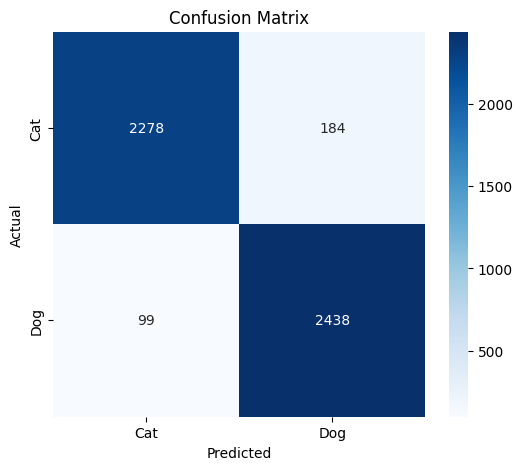

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

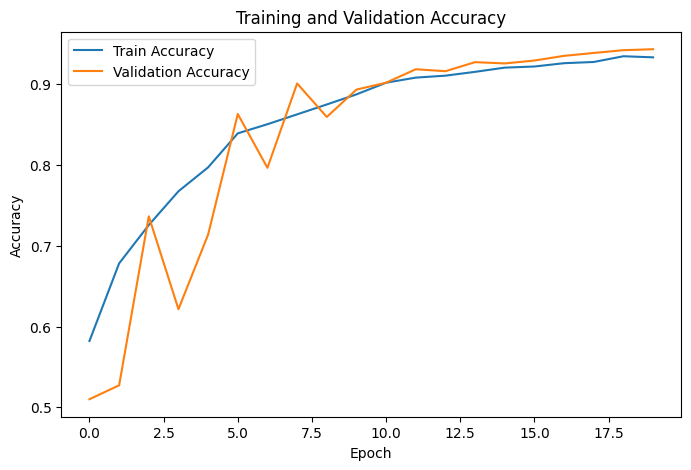

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

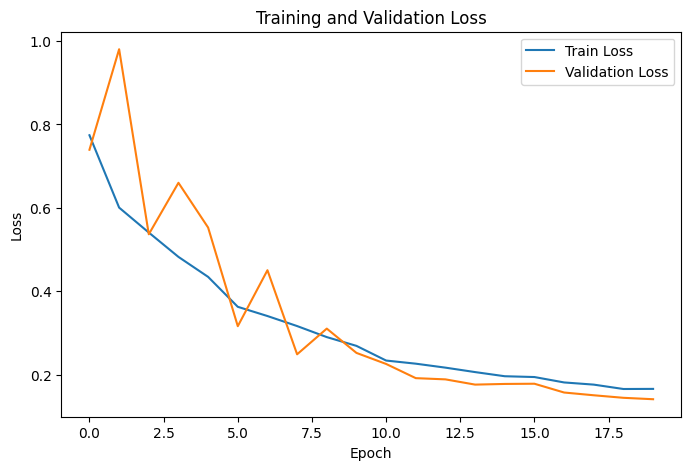

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()